In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.datasets._samples_generator import make_blobs

In [2]:
X,Y=make_blobs(n_samples=300,centers=2,n_features=2,cluster_std=5,random_state=42)

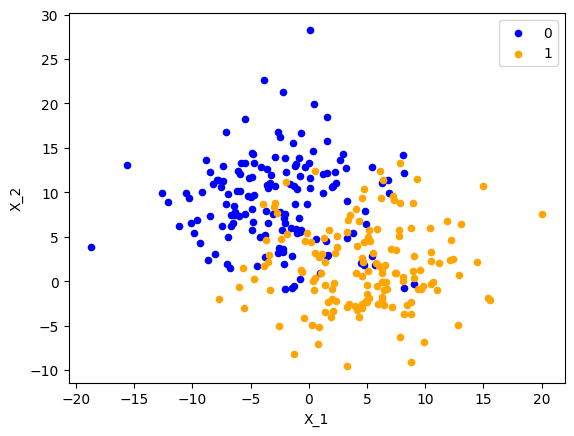

In [3]:
df = pd.DataFrame(dict(x=X[:,0], y=X[:,1], label=Y))
colors = {0:'blue', 1:'orange'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.show()

In [4]:
#splitting into branches
def next_batch(X,Y,batch_size):
    for i in np.arange(0,X.shape[0],batch_size):
        yield (X[i:i+batch_size],Y[i:i+batch_size])  
        #yield- nstead of returning once and ending the function, yield produces a value and pauses the function. The next time you call it (via next() or looping), it resumes right where 
        # it left off. This is how you create a generator that can give you one batch at a time without storing everything in memory.


In [5]:
#adding the columns of one's
X=np.c_[np.ones((X.shape[0])),X]  #c_ column‑stacking. It concatenates arrays column‑wise.
X.shape

(300, 3)

In [6]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [ ]:
#model
def hx(W,X):
    return sigmoid(np.dot(X,W))

#Hypothesis function ->rule the model used to make a decision.

In [8]:
#cost function
def cost(W,X,Y):
    y_pred=hx(W,X)
    return -1*sum(Y*np.log(y_pred)+(1-Y)*np.log(1-y_pred))

$$J(W) = -\sum_{i=1}^{n} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

$$\frac{\partial J}{\partial W} = \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial W}$$

In [ ]:
#Stochstic gradient descent
def grad(W,X,Y):
    y_pred=hx(W,X)
    A=(Y*(1-y_pred)-(1-Y)*y_pred)   #Negative log likehood  {y-y_hat}
    g=-1*np.dot(A.T,X)              #deriving the gradient (for update weights,need partial derivative of cost fun{J}wrt W)
    #we take -ve because we have minimize the negative log-likehood
    #maximize the log likehood equal to minimize the negative log likehood
    return g

In [ ]:
def sgd(w_new,w_prev,lr,batch_size,epochs):
    #shuffle prevent the model from learning the order of the data instead of actual pattern.
    #ensure every mini batch is a representative sample of the whole dataset.
    X_,Y_=shuffle(X,Y,random_state=0)
    for e in range(epochs):
        epoch_loss=[]
        X_,Y_=shuffle(X_,Y_,random_state=0)
        for(batchX,batchY) in next_batch(X_,Y_,batch_size):  #into mini batch
            w_prev=w_new
            epoch_loss.append(cost(w_prev,batchX,batchY)) #store the cost(error) of every batch
            gradient=grad(w_prev,batchX,batchY)
            w_new=w_prev-lr*gradient  #weight update
        print(np.average(epoch_loss)) #print the average loss.
    return w_new




In [11]:
W=np.random.uniform(size=(X.shape[1],))
W.shape

(3,)

In [12]:
print(W)

[0.99317798 0.3628896  0.26369924]


In [13]:
W=sgd(W,W,.009,32,200)
print(W)

16.92410034407198
11.526962558276
11.718280493217026
12.135093396817252
12.12813347875608
11.669314929510607
10.750206910585764
10.841941312726702
12.421985573217741
11.145435216227746
11.497033325309001
11.579212170819082
10.939962237249215
12.987904461890668
10.566271244179699
11.588560949420586
11.11974475237736
11.532106765610433
11.277316512513238
10.804816338568768
10.909529509028745
10.790375146051556
11.880770418386783
11.602917501617755
13.711401877935284
10.773897242994998
13.765190318991092
13.35758238915346
11.082476260881661
11.507897171587356
10.909445074480445
11.04878632284171
11.95643590677838
12.38017394651067
11.060975112069297
13.310739870236574
13.460138154905087
10.630666275029478
11.121459119705378
12.294942138180092
10.881272150601431
11.41426300973194
10.53765460526727
10.030419351613926
11.426558716770243
11.332427905504733
12.59865214607807
12.349961770645828
12.376512008411764
11.151881117442475
10.373726044727617
10.286283345861714
12.774162180679252
11.519

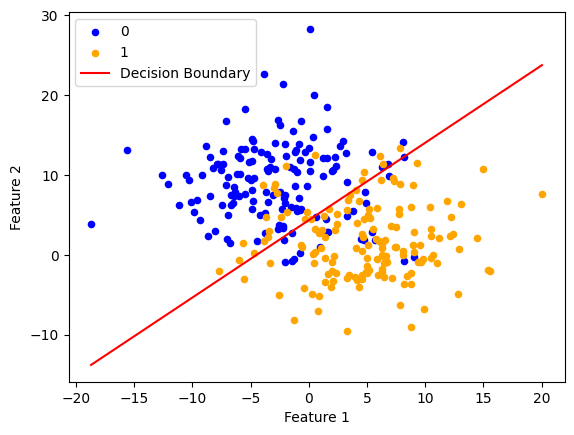

In [15]:
# Use index 1 and 2 because index 0 is now the bias (constant 1)
df = pd.DataFrame(dict(x=X[:, 1], y=X[:, 2], label=Y))
colors = {0: 'blue', 1: 'orange'}
fig, ax = plt.subplots()

grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])

# The decision boundary formula: W0 + W1*x + W2*y = 0
# Solved for y: y = (-W0 - W1*x) / W2
def my_formula(x):
    return (-W[0] - W[1]*x) / W[2]

# Adjusted range to match the scale of your blob data (e.g., -15 to 15)
x_vals = np.linspace(df.x.min(), df.x.max(), 100)
plt.plot(x_vals, my_formula(x_vals), color='red', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()